# People Analytics — Análise Exploratória de Rotatividade

## 1. Preparação do Ambiente

Este notebook apresenta a análise exploratória da base tratada de colaboradores, com foco na identificação de padrões associados à rotatividade.

Serão analisados indicadores demográficos, profissionais, financeiros e comportamentais para apoiar a geração de insights e recomendações de negócio.

In [1]:
# Importa as bibliotecas utilizadas na análise e visualização dos dados
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Configura a visualização completa das colunas e padroniza o estilo dos gráficos
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Nível de significância utilizado nos testes estatísticos
NIVEL_SIGNIFICANCIA = 0.05

# Armazena o resultado de cada teste para o resumo final
resultados_testes = []


def testar_associacao(dados, coluna, nome_exibicao):
    """Aplica o teste qui-quadrado de independência entre a variável e a rotatividade.

    Retorna o p-valor e o V de Cramér (tamanho do efeito, de 0 a 1).
    """
    tabela = pd.crosstab(dados[coluna], dados["rotatividade"])
    qui2, p_valor, graus_liberdade, _ = chi2_contingency(tabela)

    n = tabela.to_numpy().sum()
    v_cramer = np.sqrt(qui2 / (n * (min(tabela.shape) - 1)))
    significativo = p_valor < NIVEL_SIGNIFICANCIA

    resultados_testes.append({
        "variavel": nome_exibicao,
        "qui_quadrado": round(qui2, 2),
        "graus_liberdade": graus_liberdade,
        "p_valor": round(p_valor, 4),
        "v_cramer": round(v_cramer, 3),
        "significativo_5pct": "Sim" if significativo else "Não"
    })

    conclusao = (
        "associação estatisticamente significativa"
        if significativo
        else "diferença NÃO significativa (pode ser variação aleatória)"
    )
    print(
        f"{nome_exibicao}: qui² = {qui2:.2f} | gl = {graus_liberdade} | "
        f"p-valor = {p_valor:.4f} | V de Cramér = {v_cramer:.3f}"
    )
    print(f"Resultado a 5%: {conclusao}")

In [2]:
# Define o caminho relativo do arquivo CSV gerado no processo de tratamento
caminho_base_tratada = Path(
    "../data/People_Analytics_Base_Tratada.csv"
)

# Importa a base tratada e converte as colunas de data automaticamente
df = pd.read_csv(
    caminho_base_tratada,
    encoding="utf-8-sig",
    parse_dates=[
        "data_admissao",
        "data_desligamento"
    ]
)

# Exibe as primeiras linhas para validar a importação
df.head()

,colaborador_id,idade,genero,estado_civil,escolaridade,area,cargo,nivel_cargo,data_admissao,tempo_empresa_anos,salario_mensal,distancia_casa_km,horas_extras,viagens_negocio,satisfacao_trabalho,satisfacao_ambiente,equilibrio_vida_trabalho,avaliacao_desempenho,treinamentos_ultimo_ano,recebeu_promocao_5_anos,rotatividade,data_desligamento,motivo_desligamento,tempo_empresa_anos_informado
0,COL-0001,38,Masculino,Casado(a),Mestrado,Atendimento,Analista de Atendimento,3,2013-12-13,9,7800.0,11,Não,Raramente,1,1,3,3,3,Sim,Sim,2023-07-28,Falta de perspectiva de crescimento,12
1,COL-0002,61,Feminino,Casado(a),Pós-graduação,Recursos Humanos,Especialista de Pessoas,5,2025-03-07,1,12950.0,49,Não,Frequentemente,5,2,2,5,3,Não,Não,NaT,Não se aplica,1
2,COL-0003,51,Não binário,Casado(a),Graduação,Operações,Coordenador de Operações,4,2022-05-18,4,11400.0,39,Não,Raramente,4,5,4,3,4,Não,Não,NaT,Não se aplica,4
3,COL-0004,34,Feminino,União estável,Tecnólogo,Tecnologia,Analista de Dados,3,2021-05-28,5,11450.0,46,Não,Raramente,3,2,4,4,3,Não,Não,NaT,Não se aplica,4
4,COL-0005,46,Feminino,União estável,Pós-graduação,Financeiro,Controller,3,2015-11-10,10,9550.0,35,Não,Nunca,3,3,4,3,1,Sim,Não,NaT,Não se aplica,11


In [3]:
# Apresenta as dimensões e a estrutura da base utilizada na análise
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

df.info()

Quantidade de registros: 1200
Quantidade de colunas: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   colaborador_id                1200 non-null   object        
 1   idade                         1200 non-null   int64         
 2   genero                        1200 non-null   object        
 3   estado_civil                  1200 non-null   object        
 4   escolaridade                  1200 non-null   object        
 5   area                          1200 non-null   object        
 6   cargo                         1200 non-null   object        
 7   nivel_cargo                   1200 non-null   int64         
 8   data_admissao                 1200 non-null   datetime64[ns]
 9   tempo_empresa_anos            1200 non-null   int64         
 10  salario_mensal                1200 non-n

# 2. Indicadores Gerais de People Analytics

Nesta etapa, serão calculados os principais indicadores da força de trabalho, incluindo quantidade de colaboradores, desligamentos e taxa geral de rotatividade.

**Definição utilizada:** a taxa de rotatividade representa a proporção de colaboradores desligados em relação ao total de registros da base. Como os desligamentos estão distribuídos entre 2022 e 2026, trata-se de uma **taxa acumulada do período**, e não de um turnover anual. Em um contexto real de RH, o turnover costuma ser calculado por período (por exemplo, desligamentos no mês ÷ headcount médio do mês).

Para cada recorte, além da taxa, é aplicado o **teste qui-quadrado de independência**, que verifica se a diferença entre os grupos é estatisticamente significativa ou se pode ser explicada por variação aleatória.

In [4]:
# Converte a variável de rotatividade em formato numérico para facilitar os cálculos
df["rotatividade_flag"] = df["rotatividade"].map({
    "Não": 0,
    "Sim": 1
})

# Confirma se todos os registros foram convertidos corretamente
df["rotatividade_flag"].value_counts(dropna=False)

rotatividade_flag
0    877
1    323
Name: count, dtype: int64

In [5]:
# Calcula a quantidade total de colaboradores únicos
total_colaboradores = df["colaborador_id"].nunique()

# Calcula a quantidade de colaboradores ativos
total_ativos = (
    df["rotatividade"]
    .eq("Não")
    .sum()
)

# Calcula a quantidade de colaboradores desligados
total_desligados = (
    df["rotatividade"]
    .eq("Sim")
    .sum()
)

# Calcula a taxa geral de rotatividade
taxa_rotatividade = (
    total_desligados / total_colaboradores
)

# Calcula indicadores médios complementares
salario_medio = df["salario_mensal"].mean()
tempo_medio_empresa = df["tempo_empresa_anos"].mean()
idade_media = df["idade"].mean()

In [6]:
# Organiza os principais indicadores em uma tabela executiva
resumo_kpis = pd.DataFrame({
    "Indicador": [
        "Total de colaboradores",
        "Colaboradores ativos",
        "Colaboradores desligados",
        "Taxa de rotatividade",
        "Idade média",
        "Tempo médio de empresa",
        "Salário médio"
    ],
    "Valor": [
        f"{total_colaboradores:,}".replace(",", "."),
        f"{total_ativos:,}".replace(",", "."),
        f"{total_desligados:,}".replace(",", "."),
        f"{taxa_rotatividade:.2%}".replace(".", ","),
        f"{idade_media:.1f} anos".replace(".", ","),
        f"{tempo_medio_empresa:.1f} anos".replace(".", ","),
        f"R$ {salario_medio:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    ]
})

# Exibe o resumo executivo dos indicadores
resumo_kpis

,Indicador,Valor
0,Total de colaboradores,1.200
1,Colaboradores ativos,877
2,Colaboradores desligados,323
3,Taxa de rotatividade,"26,92%"
4,Idade média,"41,1 anos"
5,Tempo médio de empresa,"5,9 anos"
6,Salário médio,"R$ 9.086,42"


## 2.1 Conclusão Executiva — Indicadores Gerais

A base analisada contém 1.200 colaboradores, dos quais 877 permanecem ativos e 323 foram desligados. Isso representa uma taxa acumulada de rotatividade de 26,92% no período analisado.

Os colaboradores apresentam idade média de 41,1 anos, tempo médio de empresa de 5,9 anos (recalculado a partir das datas de admissão e desligamento) e salário mensal médio de R$ 9.086,42.

A taxa geral indica uma participação relevante de desligamentos na população analisada. Entretanto, esse indicador isolado não explica as causas da rotatividade. Por isso, as próximas etapas irão segmentar os desligamentos por área, tempo de empresa, salário, horas extras e níveis de satisfação, verificando também se as diferenças encontradas são estatisticamente significativas.

As análises representam associações presentes na base e não devem ser interpretadas, isoladamente, como relações de causa e efeito.

## 2.2 Distribuição da Rotatividade

A visualização apresenta a distribuição de colaboradores ativos e desligados, permitindo comparar a participação de cada grupo na base analisada.

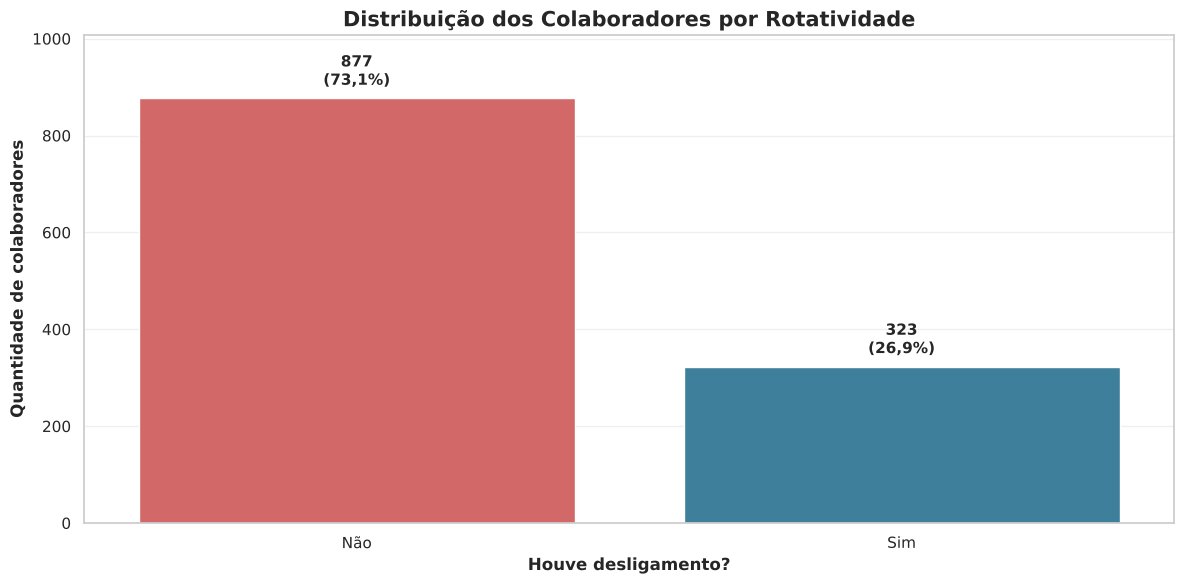

Gráfico salvo em: ../imagens/distribuicao_rotatividade.png


In [7]:
# Define a pasta e o caminho onde o gráfico será salvo
pasta_imagens = Path("../imagens")
pasta_imagens.mkdir(parents=True, exist_ok=True)

caminho_grafico = (
    pasta_imagens / "distribuicao_rotatividade.png"
)

# Define a ordem das categorias e as cores utilizadas
ordem_rotatividade = ["Não", "Sim"]
cores_rotatividade = ["#2E86AB", "#E45756"]

# Cria o gráfico de distribuição dos colaboradores
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    x="rotatividade",
    order=ordem_rotatividade,
    hue="rotatividade",
    palette=cores_rotatividade,
    legend=False
)

# Adiciona a quantidade e o percentual acima de cada barra
for barra in ax.patches:
    quantidade = int(barra.get_height())
    percentual = quantidade / len(df)

    percentual_formatado = (
        f"{percentual:.1%}".replace(".", ",")
    )

    ax.annotate(
        f"{quantidade}\n({percentual_formatado})",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Adiciona espaço acima das barras para melhorar a visualização dos rótulos
ax.set_ylim(
    0,
    max(total_ativos, total_desligados) * 1.15
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Distribuição dos Colaboradores por Rotatividade",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Houve desligamento?",
    fontweight="bold"
)
plt.ylabel(
    "Quantidade de colaboradores",
    fontweight="bold"
)

# Configura a grade e ajusta o layout
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico no notebook
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

# 3. Análise da Rotatividade por Área

A análise por área permite identificar quais setores apresentam maior proporção de desligamentos.

Para evitar interpretações equivocadas causadas por diferenças no tamanho das equipes, será calculada a taxa de rotatividade de cada área, considerando a relação entre desligados e total de colaboradores.

In [8]:
# Agrupa os colaboradores por área e calcula o total de pessoas e desligamentos
rotatividade_por_area = (
    df.groupby("area")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada área
rotatividade_por_area["taxa_rotatividade"] = (
    rotatividade_por_area["total_desligados"]
    / rotatividade_por_area["total_colaboradores"]
)

# Ordena as áreas da maior para a menor taxa de rotatividade
rotatividade_por_area = (
    rotatividade_por_area
    .sort_values(
        by="taxa_rotatividade",
        ascending=False
    )
    .reset_index(drop=True)
)

# Exibe a tabela com o percentual formatado
display(
    rotatividade_por_area.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,area,total_colaboradores,total_desligados,taxa_rotatividade
0,Atendimento,167,56,33.53%
1,Marketing,165,48,29.09%
2,Financeiro,166,45,27.11%
3,Operações,173,46,26.59%
4,Recursos Humanos,182,48,26.37%
5,Comercial,170,43,25.29%
6,Tecnologia,177,37,20.90%


In [9]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "area", "Área")

Área: qui² = 7.63 | gl = 6 | p-valor = 0.2662 | V de Cramér = 0.080
Resultado a 5%: diferença NÃO significativa (pode ser variação aleatória)


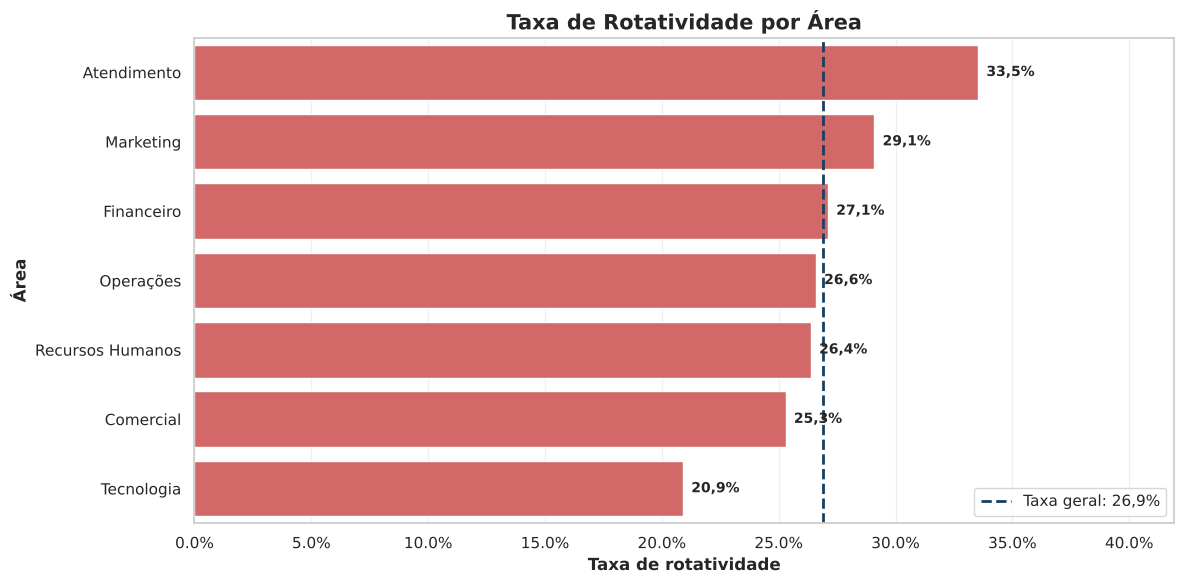

Gráfico salvo em: ../imagens/rotatividade_por_area.png


In [10]:
# Importa o formatador utilizado para apresentar o eixo em percentual
from matplotlib.ticker import PercentFormatter

# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens / "rotatividade_por_area.png"
)

# Cria o gráfico horizontal com a taxa de rotatividade por área
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_por_area,
    y="area",
    x="taxa_rotatividade",
    color="#E45756"
)

# Adiciona o percentual ao final de cada barra
for barra in ax.patches:
    taxa = barra.get_width()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            taxa,
            barra.get_y() + barra.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona uma linha de referência com a taxa geral de rotatividade
ax.axvline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Área",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Taxa de rotatividade",
    fontweight="bold"
)
plt.ylabel(
    "Área",
    fontweight="bold"
)

# Formata o eixo horizontal como percentual
ax.xaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_xlim(
    0,
    rotatividade_por_area["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="x",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 3.1 Conclusão Executiva — Rotatividade por Área

A área de Atendimento apresenta a maior taxa de rotatividade, com 33,5%, 6,6 pontos percentuais acima da taxa geral de 26,9%. Tecnologia possui a menor taxa, com 20,9%.

**Porém, o teste qui-quadrado indica que as diferenças entre as áreas não são estatisticamente significativas (p-valor = 0,27).** Com cerca de 170 colaboradores por área, variações dessa magnitude podem ocorrer por acaso. Portanto, os dados **não sustentam** a conclusão de que alguma área tenha, de fato, rotatividade estruturalmente maior.

Recomendação: não priorizar uma área com base apenas nesse resultado. O mais adequado é acompanhar a rotatividade por área ao longo do tempo (série mensal) e reavaliar quando houver mais observações.

# 4. Relação entre Horas Extras e Rotatividade

Nesta etapa, será analisada a taxa de rotatividade entre colaboradores que realizam e que não realizam horas extras.

A comparação permite verificar se existe uma associação entre carga adicional de trabalho e desligamentos, sem estabelecer uma relação direta de causalidade.

In [11]:
# Agrupa os colaboradores por realização de horas extras e calcula os desligamentos
rotatividade_horas_extras = (
    df.groupby("horas_extras")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada grupo
rotatividade_horas_extras["taxa_rotatividade"] = (
    rotatividade_horas_extras["total_desligados"]
    / rotatividade_horas_extras["total_colaboradores"]
)

# Ordena os grupos para facilitar a comparação
rotatividade_horas_extras["horas_extras"] = pd.Categorical(
    rotatividade_horas_extras["horas_extras"],
    categories=["Não", "Sim"],
    ordered=True
)

rotatividade_horas_extras = (
    rotatividade_horas_extras
    .sort_values("horas_extras")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_horas_extras.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,horas_extras,total_colaboradores,total_desligados,taxa_rotatividade
0,Não,776,199,25.64%
1,Sim,424,124,29.25%


In [12]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "horas_extras", "Horas extras")

Horas extras: qui² = 1.63 | gl = 1 | p-valor = 0.2019 | V de Cramér = 0.037
Resultado a 5%: diferença NÃO significativa (pode ser variação aleatória)


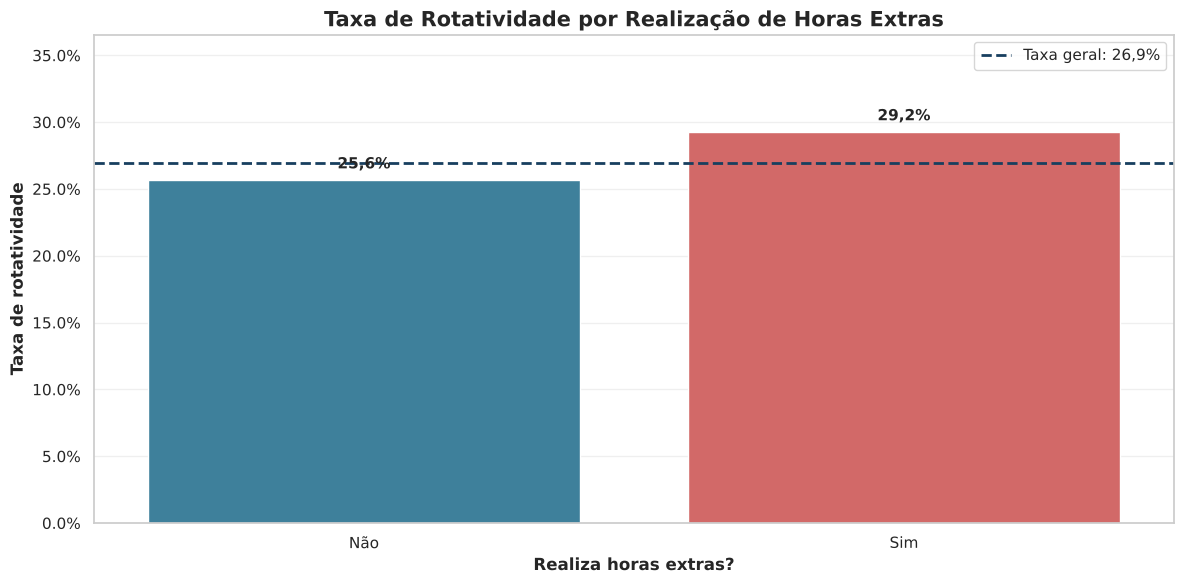

Gráfico salvo em: ../imagens/rotatividade_por_horas_extras.png


In [13]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens / "rotatividade_por_horas_extras.png"
)

# Define as cores utilizadas para diferenciar os grupos
cores_horas_extras = ["#2E86AB", "#E45756"]

# Cria o gráfico com a taxa de rotatividade por realização de horas extras
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_horas_extras,
    x="horas_extras",
    y="taxa_rotatividade",
    hue="horas_extras",
    palette=cores_horas_extras,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Realização de Horas Extras",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Realiza horas extras?",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_horas_extras["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 4.1 Conclusão Executiva — Horas Extras

Os colaboradores que realizam horas extras apresentam taxa de rotatividade de 29,2%, enquanto aqueles que não realizam possuem taxa de 25,6% — uma diferença de 3,6 pontos percentuais.

**A diferença não é estatisticamente significativa (p-valor = 0,20)** e a força da associação é muito baixa (V de Cramér = 0,04). Com os dados disponíveis, não é possível afirmar que horas extras estejam associadas a mais desligamentos.

Uma limitação importante é que a variável é apenas Sim/Não. Recomenda-se coletar a quantidade de horas extras por colaborador, o que permitiria avaliar se níveis elevados e recorrentes de sobrecarga se relacionam com a saída.

# 5. Relação entre Satisfação no Trabalho e Rotatividade

A satisfação no trabalho pode estar associada à permanência dos colaboradores na organização.

Nesta etapa, será calculada a taxa de rotatividade para cada nível de satisfação, considerando uma escala de 1 a 5, em que 1 representa satisfação muito baixa e 5 representa satisfação muito alta.

In [14]:
# Agrupa os colaboradores por nível de satisfação e calcula os desligamentos
rotatividade_satisfacao = (
    df.groupby("satisfacao_trabalho")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada nível de satisfação
rotatividade_satisfacao["taxa_rotatividade"] = (
    rotatividade_satisfacao["total_desligados"]
    / rotatividade_satisfacao["total_colaboradores"]
)

# Ordena os resultados do menor para o maior nível de satisfação
rotatividade_satisfacao = (
    rotatividade_satisfacao
    .sort_values("satisfacao_trabalho")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_satisfacao.style.format({
        "satisfacao_trabalho": "{:.0f}",
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,satisfacao_trabalho,total_colaboradores,total_desligados,taxa_rotatividade
0,1,222,73,32.88%
1,2,231,79,34.20%
2,3,267,63,23.60%
3,4,244,57,23.36%
4,5,236,51,21.61%


In [15]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "satisfacao_trabalho", "Satisfação no trabalho")

Satisfação no trabalho: qui² = 16.69 | gl = 4 | p-valor = 0.0022 | V de Cramér = 0.118
Resultado a 5%: associação estatisticamente significativa


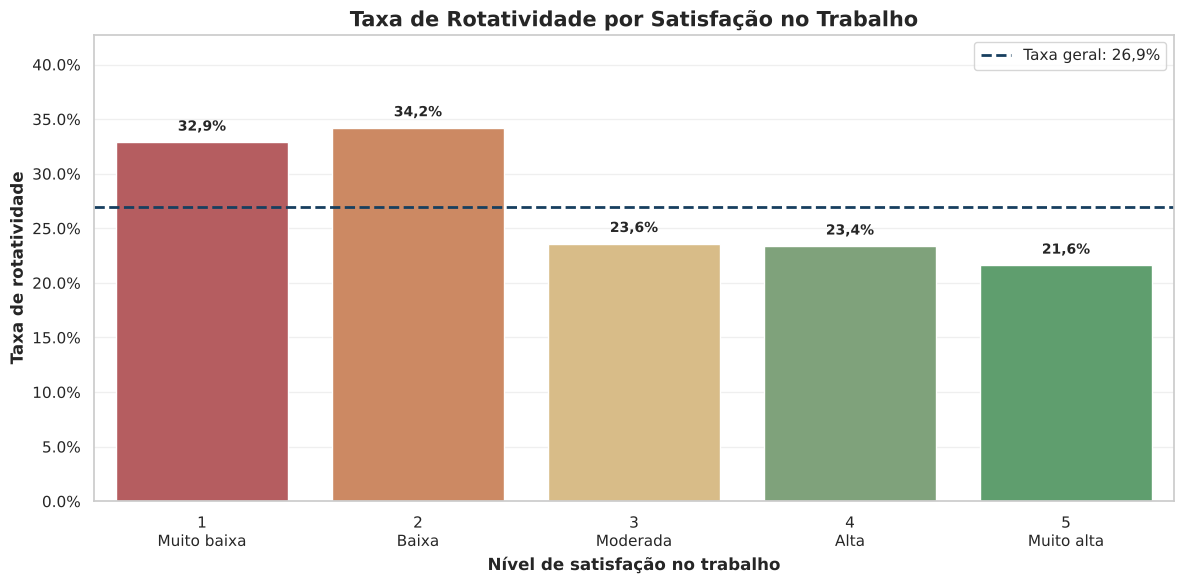

Gráfico salvo em: ../imagens/rotatividade_por_satisfacao_trabalho.png


In [16]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_satisfacao_trabalho.png"
)

# Define uma escala de cores do vermelho ao verde para representar os níveis de satisfação
cores_satisfacao = [
    "#C44E52",
    "#DD8452",
    "#E5C07B",
    "#7AA974",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por nível de satisfação
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_satisfacao,
    x="satisfacao_trabalho",
    y="taxa_rotatividade",
    hue="satisfacao_trabalho",
    palette=cores_satisfacao,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Satisfação no Trabalho",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Nível de satisfação no trabalho",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Substitui os valores da escala por descrições mais claras
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        "1\nMuito baixa",
        "2\nBaixa",
        "3\nModerada",
        "4\nAlta",
        "5\nMuito alta"
    ]
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_satisfacao["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 5.1 Conclusão Executiva — Satisfação no Trabalho

Os colaboradores com níveis baixos de satisfação apresentam as maiores taxas de rotatividade. O nível 2 registra a maior taxa, com 34,2%, seguido pelo nível 1, com 32,9%. Ambos permanecem significativamente acima da taxa geral de 26,9%.

A partir do nível 3, observa-se uma redução relevante nos desligamentos. Os colaboradores com satisfação moderada apresentam taxa de 23,6%, enquanto os níveis 4 e 5 registram 23,4% e 21,6%, respectivamente.

A diferença entre a maior taxa, observada no nível 2, e a menor taxa, registrada no nível 5, é de 12,6 pontos percentuais. Em termos relativos, a rotatividade do nível 2 é aproximadamente 58% maior que a do grupo com satisfação muito alta.

Embora não exista uma redução perfeitamente linear entre todos os níveis, os resultados revelam uma separação clara: colaboradores com satisfação baixa apresentam maior propensão ao desligamento do que aqueles com satisfação moderada ou alta.

Recomenda-se priorizar pesquisas de clima, acompanhamento da liderança, reconhecimento, oportunidades de desenvolvimento e análise da carga de trabalho entre colaboradores com avaliações de satisfação iguais ou inferiores a 2.

# 6. Rotatividade por Tempo de Empresa

Nesta etapa, os colaboradores serão agrupados de acordo com o tempo de permanência na organização.

A análise permite identificar períodos mais críticos da jornada do colaborador e apoiar ações de onboarding, desenvolvimento, reconhecimento e retenção.

In [17]:
# Define os limites e os nomes das faixas de tempo de empresa
limites_tempo_empresa = [
    -1,
    1,
    3,
    6,
    10,
    np.inf
]

nomes_faixas_tempo = [
    "Até 1 ano",
    "2 a 3 anos",
    "4 a 6 anos",
    "7 a 10 anos",
    "Acima de 10 anos"
]

# Classifica cada colaborador de acordo com o tempo de empresa
df["faixa_tempo_empresa"] = pd.cut(
    df["tempo_empresa_anos"],
    bins=limites_tempo_empresa,
    labels=nomes_faixas_tempo,
    ordered=True
)

# Confirma a quantidade de colaboradores em cada faixa
df["faixa_tempo_empresa"].value_counts(
    sort=False
)

faixa_tempo_empresa
Até 1 ano           245
2 a 3 anos          200
4 a 6 anos          247
7 a 10 anos         288
Acima de 10 anos    220
Name: count, dtype: int64

In [18]:
# Agrupa os colaboradores por faixa de tempo e calcula os desligamentos
rotatividade_tempo_empresa = (
    df.groupby(
        "faixa_tempo_empresa",
        observed=False
    )
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada faixa de tempo
rotatividade_tempo_empresa["taxa_rotatividade"] = (
    rotatividade_tempo_empresa["total_desligados"]
    / rotatividade_tempo_empresa["total_colaboradores"]
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_tempo_empresa.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,faixa_tempo_empresa,total_colaboradores,total_desligados,taxa_rotatividade
0,Até 1 ano,245,115,46.94%
1,2 a 3 anos,200,59,29.50%
2,4 a 6 anos,247,55,22.27%
3,7 a 10 anos,288,64,22.22%
4,Acima de 10 anos,220,30,13.64%


In [19]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "faixa_tempo_empresa", "Tempo de empresa")

Tempo de empresa: qui² = 76.27 | gl = 4 | p-valor = 0.0000 | V de Cramér = 0.252
Resultado a 5%: associação estatisticamente significativa


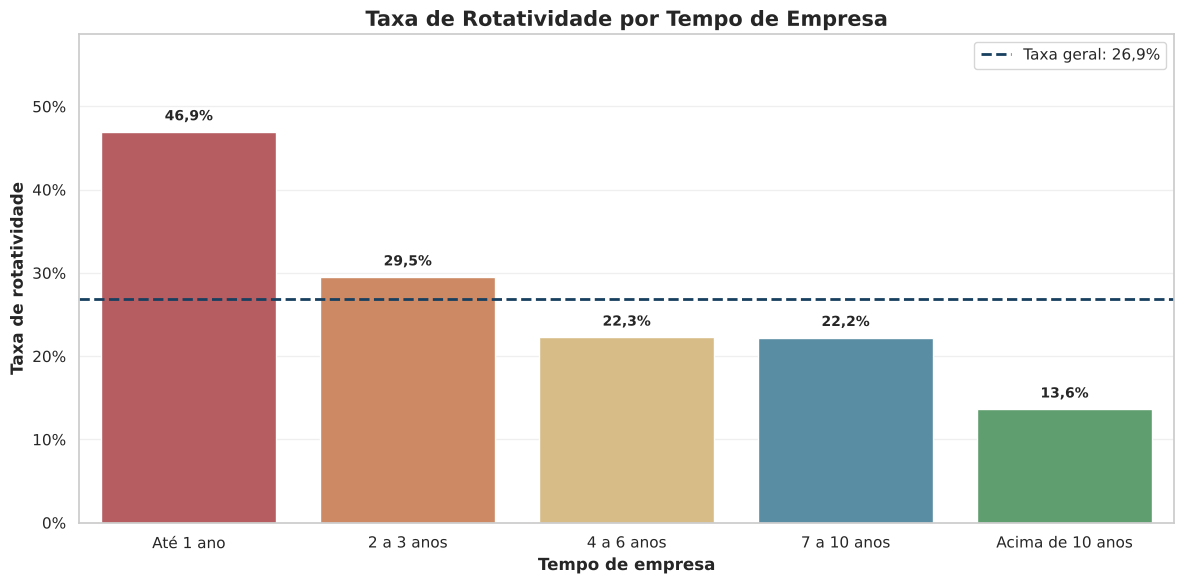

Gráfico salvo em: ../imagens/rotatividade_por_tempo_empresa.png


In [20]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_tempo_empresa.png"
)

# Define as cores utilizadas nas faixas de tempo
cores_tempo_empresa = [
    "#C44E52",
    "#DD8452",
    "#E5C07B",
    "#4C92B0",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por tempo de empresa
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_tempo_empresa,
    x="faixa_tempo_empresa",
    y="taxa_rotatividade",
    hue="faixa_tempo_empresa",
    palette=cores_tempo_empresa,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Tempo de Empresa",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Tempo de empresa",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_tempo_empresa["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 6.1 Conclusão Executiva — Tempo de Empresa

O tempo de empresa é o fator com **a associação mais forte** entre todos os analisados (p-valor < 0,001; V de Cramér = 0,25).

Os colaboradores com até 1 ano de empresa apresentam taxa de rotatividade de 46,9% — quase o dobro da taxa geral de 26,9%. Entre 2 e 3 anos, a taxa cai para 29,5%, ainda acima da média. A partir daí, o risco diminui de forma consistente: 22,3% entre 4 e 6 anos, 22,2% entre 7 e 10 anos e 13,6% acima de 10 anos.

> **Nota metodológica:** o campo `tempo_empresa_anos` foi recalculado no notebook de ETL. Na base original, o tempo dos desligados era contado até a data atual, e não até a data de saída, o que subestimava a concentração de desligamentos nos primeiros anos.

O primeiro ano é, claramente, o período mais crítico da jornada do colaborador. Recomenda-se fortalecer o onboarding, estabelecer metas de 30, 60 e 90 dias, realizar acompanhamentos periódicos com a liderança e conversas de permanência aos 3, 6 e 12 meses.

# 7. Relação entre Faixa Salarial e Rotatividade

Nesta etapa, os colaboradores serão classificados em quatro faixas salariais com quantidades semelhantes de registros.

O primeiro quartil representa os menores salários da base, enquanto o quarto quartil reúne os maiores salários. Essa divisão permite comparar a rotatividade entre diferentes níveis de remuneração.

In [21]:
# Define os nomes utilizados para representar os quartis salariais
nomes_faixas_salariais = [
    "1º quartil",
    "2º quartil",
    "3º quartil",
    "4º quartil"
]

# Divide os colaboradores em quatro faixas de acordo com a distribuição salarial
df["faixa_salarial"] = pd.qcut(
    df["salario_mensal"],
    q=4,
    labels=nomes_faixas_salariais
)

# Confirma a quantidade de colaboradores em cada faixa salarial
df["faixa_salarial"].value_counts(
    sort=False
)

faixa_salarial
1º quartil    300
2º quartil    301
3º quartil    308
4º quartil    291
Name: count, dtype: int64

In [22]:
# Agrupa os colaboradores por faixa salarial e calcula os principais indicadores
rotatividade_faixa_salarial = (
    df.groupby(
        "faixa_salarial",
        observed=False
    )
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        ),
        salario_minimo=(
            "salario_mensal",
            "min"
        ),
        salario_medio=(
            "salario_mensal",
            "mean"
        ),
        salario_maximo=(
            "salario_mensal",
            "max"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada faixa salarial
rotatividade_faixa_salarial["taxa_rotatividade"] = (
    rotatividade_faixa_salarial["total_desligados"]
    / rotatividade_faixa_salarial["total_colaboradores"]
)

# Exibe a tabela com os valores formatados
display(
    rotatividade_faixa_salarial.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "salario_minimo": "R$ {:,.2f}",
        "salario_medio": "R$ {:,.2f}",
        "salario_maximo": "R$ {:,.2f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,faixa_salarial,total_colaboradores,total_desligados,salario_minimo,salario_medio,salario_maximo,taxa_rotatividade
0,1º quartil,300,90,"R$ 3,750.00","R$ 6,257.50","R$ 7,350.00",30.00%
1,2º quartil,301,83,"R$ 7,400.00","R$ 8,205.15","R$ 9,000.00",27.57%
2,3º quartil,308,81,"R$ 9,050.00","R$ 9,888.31","R$ 10,700.00",26.30%
3,4º quartil,291,69,"R$ 10,750.00","R$ 12,065.64","R$ 14,800.00",23.71%


In [23]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "faixa_salarial", "Faixa salarial")

Faixa salarial: qui² = 3.10 | gl = 3 | p-valor = 0.3771 | V de Cramér = 0.051
Resultado a 5%: diferença NÃO significativa (pode ser variação aleatória)


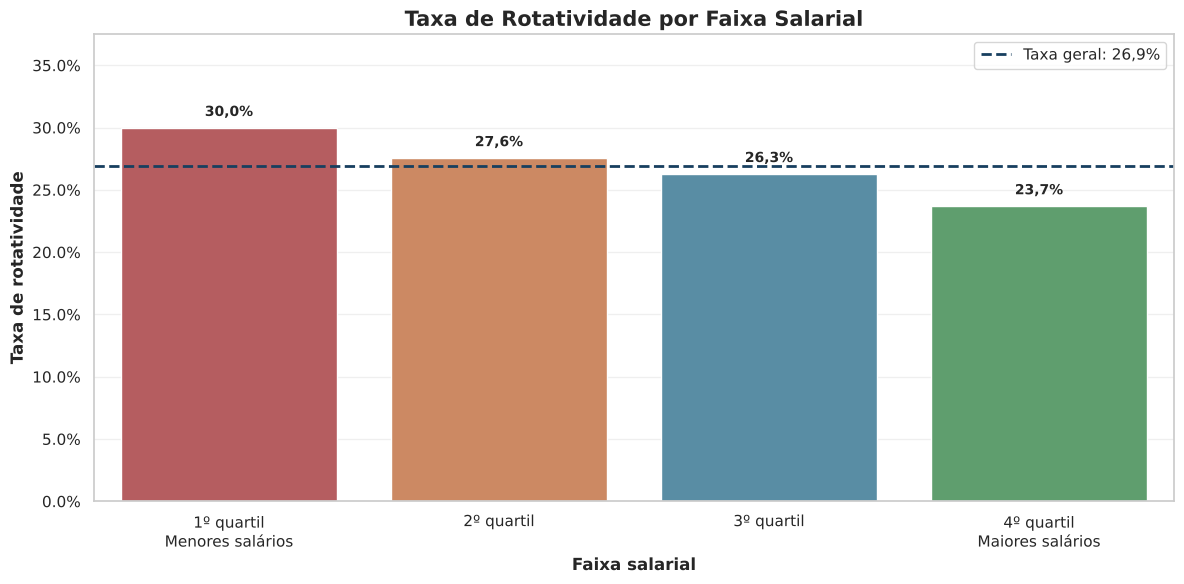

Gráfico salvo em: ../imagens/rotatividade_por_faixa_salarial.png


In [24]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_faixa_salarial.png"
)

# Define as cores utilizadas para representar os quartis salariais
cores_faixas_salariais = [
    "#C44E52",
    "#DD8452",
    "#4C92B0",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por faixa salarial
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_faixa_salarial,
    x="faixa_salarial",
    y="taxa_rotatividade",
    hue="faixa_salarial",
    palette=cores_faixas_salariais,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral de rotatividade
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Faixa Salarial",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Faixa salarial",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Acrescenta uma descrição para facilitar a leitura dos quartis
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "1º quartil\nMenores salários",
        "2º quartil",
        "3º quartil",
        "4º quartil\nMaiores salários"
    ]
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura os elementos visuais
ax.set_ylim(
    0,
    rotatividade_faixa_salarial["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 7.1 Conclusão Executiva — Faixa Salarial

O primeiro quartil (menores salários) apresenta taxa de rotatividade de 30,0%, enquanto o quarto quartil (maiores salários) registra 23,7%. As taxas diminuem gradualmente entre os quartis: 30,0%, 27,6%, 26,3% e 23,7%.

**Apesar da tendência visual, a diferença não é estatisticamente significativa (p-valor = 0,38).** Os dados não permitem afirmar que o nível salarial esteja associado à rotatividade nesta base.

Além disso, o salário está relacionado ao cargo, à senioridade e à área, e a comparação por quartil não considera a competitividade em relação ao mercado. Uma análise mais robusta compararia o salário de cada colaborador com a referência de mercado do respectivo cargo.

# 8. Relação entre Promoção e Rotatividade

Nesta etapa, será comparada a taxa de rotatividade entre colaboradores que receberam e que não receberam promoção nos últimos cinco anos.

A análise permite verificar se oportunidades de crescimento profissional estão associadas à permanência dos colaboradores.

In [25]:
# Agrupa os colaboradores pelo histórico de promoção e calcula os desligamentos
rotatividade_promocao = (
    df.groupby("recebeu_promocao_5_anos")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada grupo
rotatividade_promocao["taxa_rotatividade"] = (
    rotatividade_promocao["total_desligados"]
    / rotatividade_promocao["total_colaboradores"]
)

# Define uma ordem lógica para apresentação dos resultados
rotatividade_promocao["recebeu_promocao_5_anos"] = pd.Categorical(
    rotatividade_promocao["recebeu_promocao_5_anos"],
    categories=["Não", "Sim"],
    ordered=True
)

rotatividade_promocao = (
    rotatividade_promocao
    .sort_values("recebeu_promocao_5_anos")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_promocao.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,recebeu_promocao_5_anos,total_colaboradores,total_desligados,taxa_rotatividade
0,Não,901,257,28.52%
1,Sim,299,66,22.07%


In [26]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "recebeu_promocao_5_anos", "Promoção nos últimos 5 anos")

Promoção nos últimos 5 anos: qui² = 4.43 | gl = 1 | p-valor = 0.0354 | V de Cramér = 0.061
Resultado a 5%: associação estatisticamente significativa


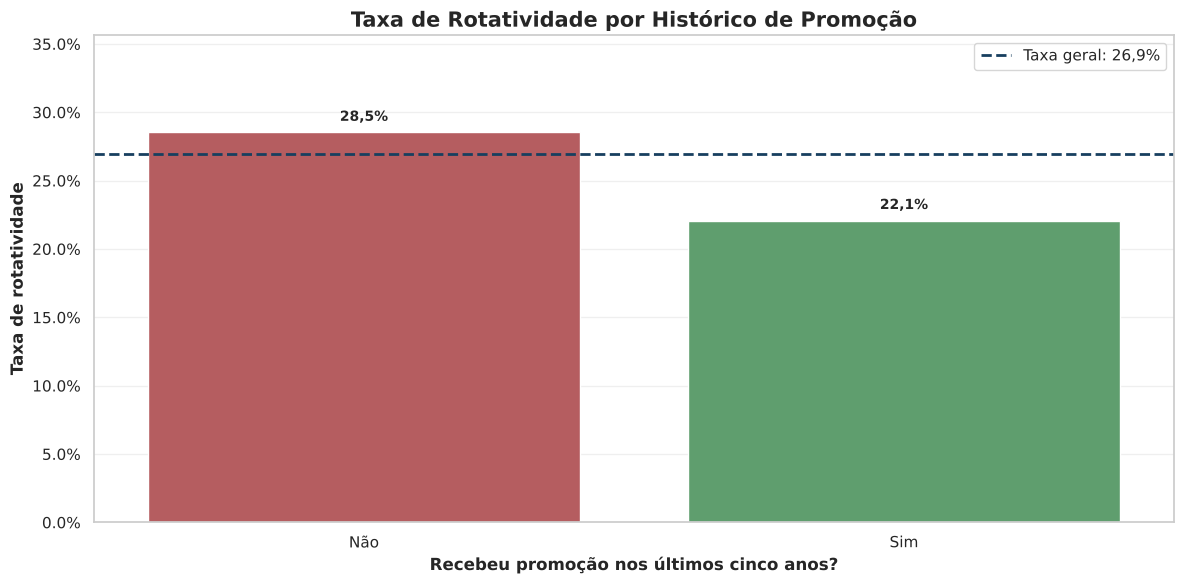

Gráfico salvo em: ../imagens/rotatividade_por_promocao.png


In [27]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_promocao.png"
)

# Define as cores dos grupos analisados
cores_promocao = [
    "#C44E52",
    "#55A868"
]

# Cria o gráfico da taxa de rotatividade por histórico de promoção
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_promocao,
    x="recebeu_promocao_5_anos",
    y="taxa_rotatividade",
    hue="recebeu_promocao_5_anos",
    palette=cores_promocao,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os eixos em negrito
plt.title(
    "Taxa de Rotatividade por Histórico de Promoção",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Recebeu promoção nos últimos cinco anos?",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Ajusta o espaço, a grade e a legenda
ax.set_ylim(
    0,
    rotatividade_promocao["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 8.1 Conclusão Executiva — Promoção

Colaboradores sem promoção nos últimos cinco anos apresentam taxa de rotatividade de 28,5%, contra 22,1% entre os promovidos — uma diferença de 6,4 pontos percentuais.

A diferença é **estatisticamente significativa (p-valor = 0,035)**, porém a força da associação é baixa (V de Cramér = 0,06). Há também um fator de confusão relevante: colaboradores com pouco tempo de casa naturalmente tiveram menos oportunidade de ser promovidos, e são justamente eles que apresentam maior rotatividade.

Recomenda-se estruturar critérios transparentes de promoção e mobilidade interna, e aprofundar a análise considerando apenas colaboradores com mais de 2 anos de empresa.

# 9. Equilíbrio entre Vida Pessoal e Trabalho

Nesta etapa, será analisada a taxa de rotatividade para cada nível de equilíbrio entre vida pessoal e trabalho.

A variável utiliza uma escala de 1 a 5, em que valores menores representam uma percepção mais negativa de equilíbrio.

In [28]:
# Agrupa os colaboradores por nível de equilíbrio e calcula os desligamentos
rotatividade_equilibrio = (
    df.groupby("equilibrio_vida_trabalho")
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada nível de equilíbrio
rotatividade_equilibrio["taxa_rotatividade"] = (
    rotatividade_equilibrio["total_desligados"]
    / rotatividade_equilibrio["total_colaboradores"]
)

# Ordena os resultados de acordo com o nível de equilíbrio
rotatividade_equilibrio = (
    rotatividade_equilibrio
    .sort_values("equilibrio_vida_trabalho")
    .reset_index(drop=True)
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_equilibrio.style.format({
        "equilibrio_vida_trabalho": "{:.0f}",
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,equilibrio_vida_trabalho,total_colaboradores,total_desligados,taxa_rotatividade
0,1,230,77,33.48%
1,2,255,76,29.80%
2,3,232,59,25.43%
3,4,236,51,21.61%
4,5,247,60,24.29%


In [29]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "equilibrio_vida_trabalho", "Equilíbrio vida-trabalho")

Equilíbrio vida-trabalho: qui² = 10.62 | gl = 4 | p-valor = 0.0312 | V de Cramér = 0.094
Resultado a 5%: associação estatisticamente significativa


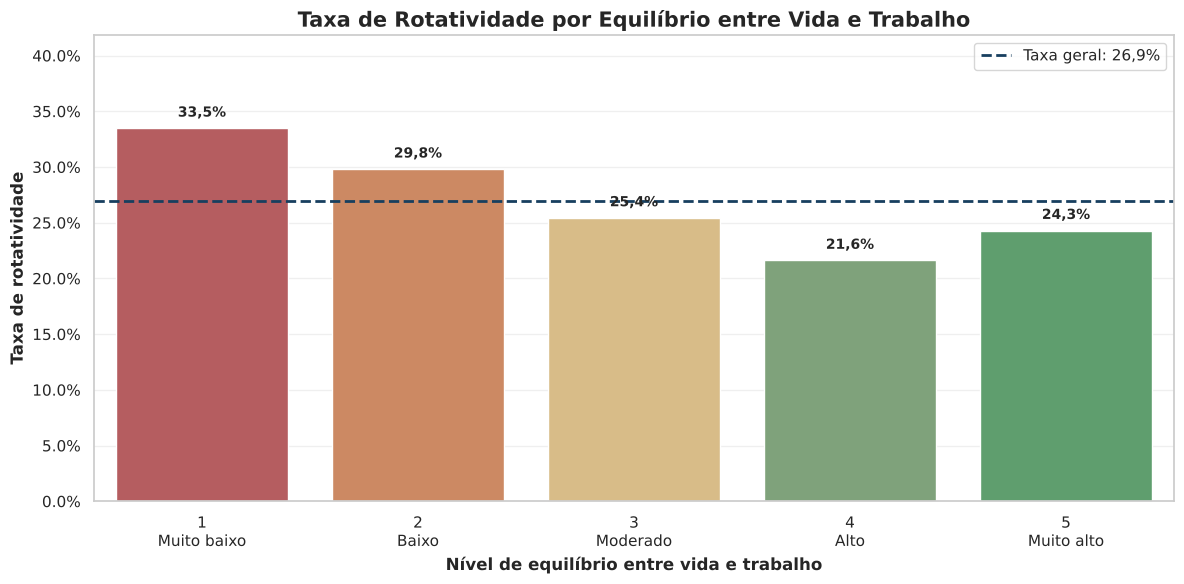

Gráfico salvo em: ../imagens/rotatividade_por_equilibrio_vida_trabalho.png


In [30]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_equilibrio_vida_trabalho.png"
)

# Define uma escala de cores do vermelho ao verde
cores_equilibrio = [
    "#C44E52",
    "#DD8452",
    "#E5C07B",
    "#7AA974",
    "#55A868"
]

# Cria o gráfico com a taxa de rotatividade por nível de equilíbrio
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_equilibrio,
    x="equilibrio_vida_trabalho",
    y="taxa_rotatividade",
    hue="equilibrio_vida_trabalho",
    palette=cores_equilibrio,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Equilíbrio entre Vida e Trabalho",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Nível de equilíbrio entre vida e trabalho",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Substitui os valores da escala por descrições
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        "1\nMuito baixo",
        "2\nBaixo",
        "3\nModerado",
        "4\nAlto",
        "5\nMuito alto"
    ]
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura o layout
ax.set_ylim(
    0,
    rotatividade_equilibrio["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 9.1 Conclusão Executiva — Equilíbrio entre Vida e Trabalho

Os colaboradores que avaliam o equilíbrio entre vida pessoal e trabalho como muito baixo (nível 1) apresentam a maior taxa de rotatividade, com 33,5%. O nível 2 registra 29,8%. A partir do nível 3, os resultados ficam abaixo da taxa geral: 25,4% no nível 3, 21,6% no nível 4 e 24,3% no nível 5.

A associação é **estatisticamente significativa (p-valor = 0,031)**, com intensidade fraca (V de Cramér = 0,09). Existe uma separação entre os colaboradores com equilíbrio baixo (níveis 1 e 2) e os demais.

Recomenda-se acompanhar a carga de trabalho, a flexibilidade e a qualidade da liderança, utilizando pesquisas periódicas para identificar sinais de sobrecarga antes que resultem em desligamentos.

# 10. Motivos de Desligamento

A base registra o motivo principal de cada desligamento. Essa informação ajuda a responder diretamente **por que** os colaboradores saíram e complementa as associações observadas nas seções anteriores.

In [31]:
# Seleciona apenas os colaboradores desligados
desligados = df[df["rotatividade"] == "Sim"]

# Calcula a quantidade e a participação de cada motivo de desligamento
motivos_desligamento = (
    desligados["motivo_desligamento"]
    .value_counts()
    .rename_axis("motivo_desligamento")
    .reset_index(name="total_desligados")
)

motivos_desligamento["participacao"] = (
    motivos_desligamento["total_desligados"]
    / motivos_desligamento["total_desligados"].sum()
)

display(
    motivos_desligamento.style.format({
        "total_desligados": "{:,.0f}",
        "participacao": "{:.1%}"
    })
)

,motivo_desligamento,total_desligados,participacao
0,Nova oportunidade profissional,53,16.4%
1,Qualidade de vida,50,15.5%
2,Falta de perspectiva de crescimento,46,14.2%
3,Mudança de cidade,46,14.2%
4,Desempenho abaixo do esperado,45,13.9%
5,Remuneração e benefícios,42,13.0%
6,Reestruturação organizacional,41,12.7%


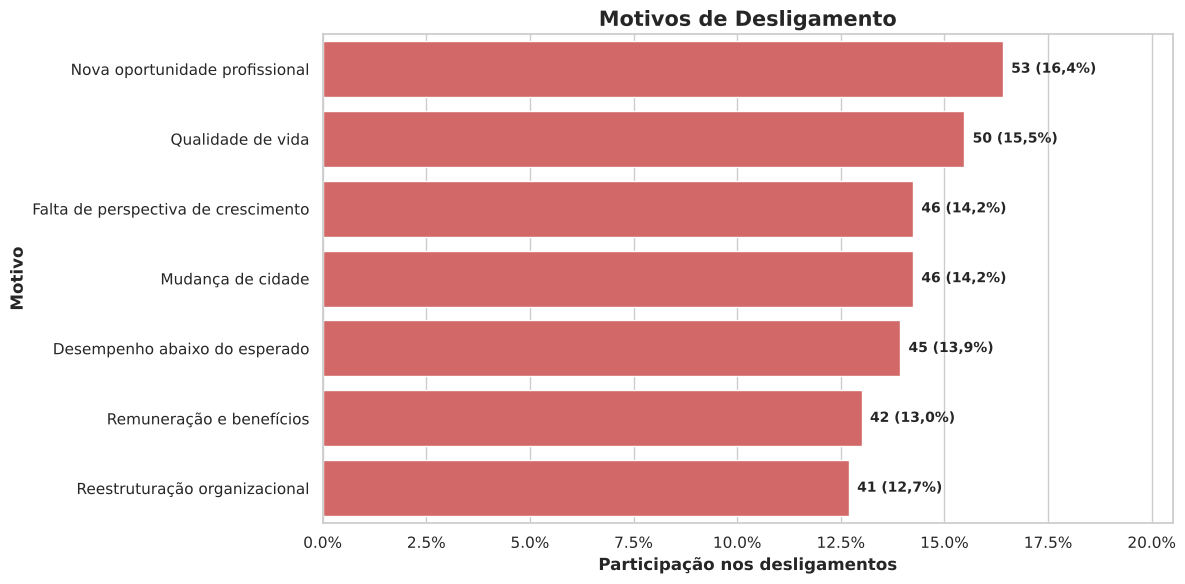

Gráfico salvo em: ../imagens/motivos_desligamento.png


In [32]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "motivos_desligamento.png"
)

# Cria o gráfico horizontal com a participação de cada motivo
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=motivos_desligamento,
    y="motivo_desligamento",
    x="participacao",
    color="#E45756"
)

# Adiciona a quantidade e o percentual ao final de cada barra
for barra, quantidade in zip(ax.patches, motivos_desligamento["total_desligados"]):
    participacao = barra.get_width()

    ax.annotate(
        f"{quantidade} ({participacao:.1%})".replace(".", ","),
        xy=(
            participacao,
            barra.get_y() + barra.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Motivos de Desligamento",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Participação nos desligamentos",
    fontweight="bold"
)
plt.ylabel(
    "Motivo",
    fontweight="bold"
)

# Formata o eixo horizontal como percentual e adiciona espaço para os rótulos
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, motivos_desligamento["participacao"].max() * 1.25)

plt.tight_layout()

# Salva o gráfico em alta resolução
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {caminho_grafico}")

In [33]:
# Cruza os motivos de desligamento com as áreas para identificar concentrações
pd.crosstab(
    desligados["area"],
    desligados["motivo_desligamento"],
    margins=True,
    margins_name="Total"
)

motivo_desligamento,Desempenho abaixo do esperado,Falta de perspectiva de crescimento,Mudança de cidade,Nova oportunidade profissional,Qualidade de vida,Reestruturação organizacional,Remuneração e benefícios,Total
area,,,,,,,,
Atendimento,7,4,13,6,10,10,6,56
Comercial,6,6,6,9,7,7,2,43
Financeiro,5,5,6,12,6,5,6,45
Marketing,9,8,7,5,7,9,3,48
Operações,8,8,8,5,7,0,10,46
Recursos Humanos,6,9,2,8,7,6,10,48
Tecnologia,4,6,4,8,6,4,5,37
Total,45,46,46,53,50,41,42,323


## 10.1 Conclusão Executiva — Motivos de Desligamento

Os motivos estão distribuídos de forma equilibrada, sem um fator dominante: Nova oportunidade profissional (16,4%), Qualidade de vida (15,5%), Falta de perspectiva de crescimento (14,2%), Mudança de cidade (14,2%), Desempenho abaixo do esperado (13,9%), Remuneração e benefícios (13,0%) e Reestruturação organizacional (12,7%).

Uma leitura útil é separar os desligamentos em dois grupos:

- **Iniciativa da empresa** (desempenho abaixo do esperado e reestruturação): cerca de 27% das saídas. Esses casos não são, necessariamente, um problema de retenção;
- **Iniciativa do colaborador** (os demais motivos): cerca de 73% das saídas, onde se concentram as oportunidades de ação.

Entre os motivos voluntários, *Falta de perspectiva de crescimento* e *Remuneração e benefícios* somam 27% dos desligamentos e se conectam diretamente com o resultado de promoção. *Qualidade de vida* (15,5%) reforça o achado sobre equilíbrio entre vida e trabalho.

Recomenda-se que as próximas análises calculem a **rotatividade voluntária** separadamente, pois ela é o indicador mais diretamente influenciado pelas ações de retenção.

# 11. Acúmulo de Fatores Associados à Rotatividade

Nesta etapa, serão combinados cinco fatores que apresentaram associação com maior rotatividade:

- satisfação no trabalho baixa;
- equilíbrio entre vida e trabalho baixo;
- realização de horas extras;
- até três anos de empresa;
- pertencimento à menor faixa salarial.

> **Atenção — leitura circular:** esses fatores foram escolhidos justamente porque apresentaram taxas maiores **nesta mesma base**. Por isso, é esperado que a taxa aumente à medida que eles se acumulam. O resultado ilustra o efeito combinado, mas não constitui uma validação independente. Uma validação adequada exigiria um modelo (por exemplo, regressão logística) avaliado em dados separados dos utilizados para escolher os fatores.

O indicador possui finalidade exclusivamente exploratória. Ele não deve ser utilizado isoladamente para avaliar colaboradores ou tomar decisões individuais.

In [34]:
# Cria indicadores binários para cada fator associado à maior rotatividade
df["fator_satisfacao_baixa"] = (
    df["satisfacao_trabalho"]
    .le(2)
    .astype(int)
)

df["fator_equilibrio_baixo"] = (
    df["equilibrio_vida_trabalho"]
    .le(2)
    .astype(int)
)

df["fator_horas_extras"] = (
    df["horas_extras"]
    .eq("Sim")
    .astype(int)
)

df["fator_pouco_tempo_empresa"] = (
    df["tempo_empresa_anos"]
    .le(3)
    .astype(int)
)

df["fator_menor_faixa_salarial"] = (
    df["faixa_salarial"]
    .eq("1º quartil")
    .astype(int)
)

In [35]:
# Define as colunas utilizadas no cálculo do indicador exploratório
colunas_fatores = [
    "fator_satisfacao_baixa",
    "fator_equilibrio_baixo",
    "fator_horas_extras",
    "fator_pouco_tempo_empresa",
    "fator_menor_faixa_salarial"
]

# Calcula quantos fatores estão presentes em cada registro
df["quantidade_fatores"] = (
    df[colunas_fatores]
    .sum(axis=1)
)

# Exibe a distribuição da quantidade de fatores encontrados
df["quantidade_fatores"].value_counts(
    sort=False
)

quantidade_fatores
1    370
2    384
0    148
3    232
4     57
5      9
Name: count, dtype: int64

In [36]:
# Agrupa a quantidade de fatores em categorias de fácil interpretação
df["grupo_fatores"] = pd.cut(
    df["quantidade_fatores"],
    bins=[
        -1,
        0,
        1,
        2,
        5
    ],
    labels=[
        "Nenhum fator",
        "1 fator",
        "2 fatores",
        "3 ou mais fatores"
    ],
    ordered=True
)

# Confirma a quantidade de colaboradores em cada grupo
df["grupo_fatores"].value_counts(
    sort=False
)

grupo_fatores
Nenhum fator         148
1 fator              370
2 fatores            384
3 ou mais fatores    298
Name: count, dtype: int64

In [37]:
# Agrupa os colaboradores pela quantidade acumulada de fatores
rotatividade_fatores = (
    df.groupby(
        "grupo_fatores",
        observed=False
    )
    .agg(
        total_colaboradores=(
            "colaborador_id",
            "nunique"
       
        ),
        total_desligados=(
            "rotatividade_flag",
            "sum"
        )
    )
    .reset_index()
)

# Calcula a taxa de rotatividade de cada grupo
rotatividade_fatores["taxa_rotatividade"] = (
    rotatividade_fatores["total_desligados"]
    / rotatividade_fatores["total_colaboradores"]
)

# Exibe a tabela com os resultados formatados
display(
    rotatividade_fatores.style.format({
        "total_colaboradores": "{:,.0f}",
        "total_desligados": "{:,.0f}",
        "taxa_rotatividade": "{:.2%}"
    })
)

,grupo_fatores,total_colaboradores,total_desligados,taxa_rotatividade
0,Nenhum fator,148,16,10.81%
1,1 fator,370,77,20.81%
2,2 fatores,384,112,29.17%
3,3 ou mais fatores,298,118,39.60%


In [38]:
# Testa se a diferença de rotatividade entre os grupos é estatisticamente significativa
testar_associacao(df, "grupo_fatores", "Acúmulo de fatores")

Acúmulo de fatores: qui² = 51.88 | gl = 3 | p-valor = 0.0000 | V de Cramér = 0.208
Resultado a 5%: associação estatisticamente significativa


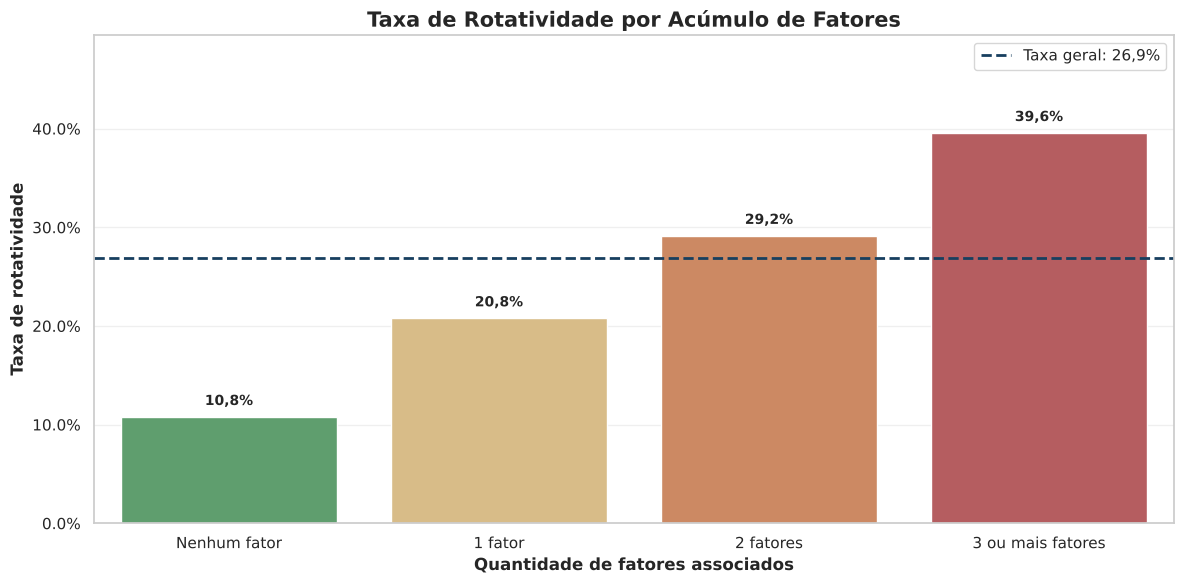

Gráfico salvo em: ../imagens/rotatividade_por_acumulo_de_fatores.png


In [39]:
# Define o caminho onde o gráfico será salvo
caminho_grafico = (
    pasta_imagens
    / "rotatividade_por_acumulo_de_fatores.png"
)

# Define uma escala de cores conforme o acúmulo de fatores
cores_fatores = [
    "#55A868",
    "#E5C07B",
    "#DD8452",
    "#C44E52"
]

# Cria o gráfico com a taxa de rotatividade por acúmulo de fatores
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=rotatividade_fatores,
    x="grupo_fatores",
    y="taxa_rotatividade",
    hue="grupo_fatores",
    palette=cores_fatores,
    legend=False
)

# Adiciona o percentual acima de cada barra
for barra in ax.patches:
    taxa = barra.get_height()

    taxa_formatada = (
        f"{taxa:.1%}".replace(".", ",")
    )

    ax.annotate(
        taxa_formatada,
        xy=(
            barra.get_x() + barra.get_width() / 2,
            taxa
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Adiciona a linha de referência da taxa geral
ax.axhline(
    taxa_rotatividade,
    color="#173F5F",
    linestyle="--",
    linewidth=2,
    label=(
        "Taxa geral: "
        f"{taxa_rotatividade:.1%}".replace(".", ",")
    )
)

# Configura o título e os nomes dos eixos em negrito
plt.title(
    "Taxa de Rotatividade por Acúmulo de Fatores",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Quantidade de fatores associados",
    fontweight="bold"
)
plt.ylabel(
    "Taxa de rotatividade",
    fontweight="bold"
)

# Formata o eixo vertical como percentual
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

# Adiciona espaço para os rótulos e configura o layout
ax.set_ylim(
    0,
    rotatividade_fatores["taxa_rotatividade"].max() * 1.25
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.legend()
plt.tight_layout()

# Salva o gráfico em alta resolução antes de exibi-lo
plt.savefig(
    caminho_grafico,
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

# Confirma o local onde o arquivo foi salvo
print(f"Gráfico salvo em: {caminho_grafico}")

## 11.1 Conclusão Executiva — Acúmulo de Fatores

A taxa de rotatividade aumenta progressivamente conforme os fatores se acumulam:

- Nenhum fator: 10,8%
- 1 fator: 20,8%
- 2 fatores: 29,2%
- 3 ou mais fatores: 39,6%

A rotatividade do grupo com três ou mais fatores é aproximadamente 3,7 vezes maior que a do grupo sem fatores.

Como explicado na introdução desta seção, esse resultado é parcialmente circular, pois os fatores foram selecionados nos mesmos dados. Além disso, dois dos cinco fatores (horas extras e menor faixa salarial) não apresentaram associação significativa isoladamente. A maior parte do efeito vem do tempo de empresa, da satisfação e do equilíbrio entre vida e trabalho.

O indicador deve ser utilizado apenas em análises agregadas, para priorização de políticas e monitoramento de grupos, nunca para classificar ou tomar decisões sobre colaboradores individualmente.

## 11.2 Resumo dos Testes Estatísticos

A tabela consolida o teste qui-quadrado de todos os recortes analisados. O **p-valor** indica a probabilidade de observar uma diferença igual ou maior caso não existisse relação real; valores abaixo de 0,05 são considerados significativos. O **V de Cramér** mede a força da associação (valores próximos de 0 indicam associação fraca).

In [40]:
# Consolida os resultados dos testes em uma tabela ordenada pelo p-valor
resumo_testes = (
    pd.DataFrame(resultados_testes)
    .sort_values("p_valor")
    .reset_index(drop=True)
)

resumo_testes

,variavel,qui_quadrado,graus_liberdade,p_valor,v_cramer,significativo_5pct
0,Tempo de empresa,76.27,4,0.0000,0.252,Sim
1,Acúmulo de fatores,51.88,3,0.0000,0.208,Sim
2,Satisfação no trabalho,16.69,4,0.0022,0.118,Sim
3,Equilíbrio vida-trabalho,10.62,4,0.0312,0.094,Sim
4,Promoção nos últimos 5 anos,4.43,1,0.0354,0.061,Sim
5,Horas extras,1.63,1,0.2019,0.037,Não
6,Área,7.63,6,0.2662,0.080,Não
7,Faixa salarial,3.10,3,0.3771,0.051,Não


# 12. Conclusão Executiva Final

## Visão Geral

A análise foi realizada sobre uma base bruta de 1.212 registros de colaboradores. Durante o tratamento, foram removidas 12 duplicidades, tratados 43 valores ausentes e recalculado o tempo de empresa a partir das datas. A base final contém 1.200 registros únicos, com 323 desligamentos e taxa acumulada de rotatividade de 26,92%.

## Fatores com associação estatisticamente significativa

| Fator | Resultado | p-valor | Força da associação |
|---|---|---|---|
| Tempo de empresa | 46,9% de rotatividade no primeiro ano, contra 13,6% acima de 10 anos | < 0,001 | Moderada |
| Satisfação no trabalho | 32,9% a 34,2% nos níveis 1 e 2, contra 21,6% no nível 5 | 0,002 | Fraca |
| Equilíbrio vida-trabalho | 33,5% no nível 1, contra 21,6% no nível 4 | 0,031 | Fraca |
| Promoção nos últimos 5 anos | 28,5% sem promoção, contra 22,1% com promoção | 0,035 | Fraca |

## Diferenças observadas, mas não significativas

| Fator | Resultado | p-valor |
|---|---|---|
| Horas extras | 29,2% com horas extras, contra 25,6% sem | 0,20 |
| Área | 33,5% em Atendimento, contra 20,9% em Tecnologia | 0,27 |
| Faixa salarial | 30,0% no 1º quartil, contra 23,7% no 4º quartil | 0,38 |

Esses resultados não devem orientar decisões isoladamente, mas podem ser monitorados ao longo do tempo.

## Motivos de desligamento

Os motivos estão distribuídos de forma equilibrada. Cerca de 27% das saídas foram de iniciativa da empresa (desempenho e reestruturação) e 73% de iniciativa do colaborador, com destaque para nova oportunidade profissional, qualidade de vida e falta de perspectiva de crescimento.

## Mensagem principal

**O principal ponto de atenção é o primeiro ano do colaborador.** Quase metade dos colaboradores nessa faixa foi desligada. Ações de onboarding e acompanhamento inicial, combinadas com atenção à satisfação, ao equilíbrio entre vida e trabalho e à perspectiva de carreira, são as que têm maior respaldo nos dados.

# 13. Decisões Orientadas pelos Dados

As recomendações estão ordenadas pela força da evidência encontrada.

| Evidência encontrada | Força da evidência | Decisão recomendada | Ação prática | Indicador de acompanhamento |
|---|---|---|---|---|
| 46,9% de rotatividade no primeiro ano | Forte (p < 0,001) | Reestruturar a jornada inicial do colaborador | Onboarding com metas de 30, 60 e 90 dias e conversas de permanência aos 3, 6 e 12 meses | Rotatividade em até 12 meses de casa |
| Satisfação baixa: rotatividade acima de 32% | Moderada (p = 0,002) | Criar ações direcionadas de clima e liderança | Pesquisas rápidas, desenvolvimento de gestores e planos de ação | Satisfação média e rotatividade |
| Equilíbrio muito baixo: 33,5% | Fraca (p = 0,031) | Ampliar políticas de equilíbrio e bem-estar | Avaliar flexibilidade, escalas e carga de trabalho | Índice de equilíbrio |
| Sem promoção: 28,5% contra 22,1% | Fraca (p = 0,035) | Estruturar carreira e mobilidade interna | Critérios transparentes de promoção e trilhas de carreira | Taxa de promoção e rotatividade voluntária |
| 73% das saídas são voluntárias | Descritiva | Monitorar a rotatividade voluntária separadamente | Separar desligamentos voluntários e involuntários nos indicadores | Rotatividade voluntária mensal |
| Diferenças por área, salário e horas extras | Não significativa | Não priorizar ações com base nesses recortes | Monitorar a série histórica e coletar dados mais detalhados (horas extras em quantidade, salário vs. mercado) | Rotatividade mensal por área |

# 14. Finalização Técnica e Exportação dos Resultados

Nesta etapa, será exportada uma base analítica enriquecida com as variáveis criadas durante a análise.

Também será gerado um arquivo Excel com os KPIs e as tabelas de resumo, facilitando a construção do dashboard no Power BI e a documentação do projeto no GitHub.

In [41]:
# Organiza os principais KPIs em uma tabela numérica para exportação
kpis_exportacao = pd.DataFrame({
    "indicador": [
        "Total de colaboradores",
        "Colaboradores ativos",
        "Colaboradores desligados",
        "Taxa de rotatividade",
        "Idade média",
        "Tempo médio de empresa",
        "Salário médio"
    ],
    "valor": [
        total_colaboradores,
        total_ativos,
        total_desligados,
        taxa_rotatividade,
        idade_media,
        tempo_medio_empresa,
        salario_medio
    ],
    "unidade": [
        "colaboradores",
        "colaboradores",
        "colaboradores",
        "percentual",
        "anos",
        "anos",
        "reais"
    ]
})

# Exibe os KPIs que serão utilizados nos arquivos finais
kpis_exportacao

,indicador,valor,unidade
0,Total de colaboradores,1200.000000,colaboradores
1,Colaboradores ativos,877.000000,colaboradores
2,Colaboradores desligados,323.000000,colaboradores
3,Taxa de rotatividade,0.269167,percentual
4,Idade média,41.078333,anos
5,Tempo médio de empresa,5.862500,anos
6,Salário médio,9086.416667,reais


In [42]:
# Define e cria os diretórios utilizados nas exportações finais
pasta_dados = Path("../data")
pasta_powerbi = Path("../powerBi")

pasta_dados.mkdir(
    parents=True,
    exist_ok=True
)

pasta_powerbi.mkdir(
    parents=True,
    exist_ok=True
)

In [43]:
# Define o caminho do arquivo com os principais indicadores do projeto
caminho_kpis = (
    pasta_dados
    / "People_Analytics_Resumo_KPIs.csv"
)

# Exporta os KPIs em formato CSV
kpis_exportacao.to_csv(
    caminho_kpis,
    index=False,
    encoding="utf-8-sig"
)

In [44]:
# Define o caminho do arquivo Excel com as tabelas executivas
caminho_resumo_excel = (
    pasta_powerbi
    / "People_Analytics_Resumo_Executivo.xlsx"
)

# Exporta os KPIs e as tabelas analíticas para diferentes planilhas
with pd.ExcelWriter(
    caminho_resumo_excel,
    engine="openpyxl"
) as writer:

    kpis_exportacao.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    rotatividade_por_area.to_excel(
        writer,
        sheet_name="Por Área",
        index=False
    )

    rotatividade_horas_extras.to_excel(
        writer,
        sheet_name="Horas Extras",
        index=False
    )

    rotatividade_satisfacao.to_excel(
        writer,
        sheet_name="Satisfação",
        index=False
    )

    rotatividade_tempo_empresa.to_excel(
        writer,
        sheet_name="Tempo de Empresa",
        index=False
    )

    rotatividade_faixa_salarial.to_excel(
        writer,
        sheet_name="Faixa Salarial",
        index=False
    )

    rotatividade_promocao.to_excel(
        writer,
        sheet_name="Promoção",
        index=False
    )

    rotatividade_equilibrio.to_excel(
        writer,
        sheet_name="Equilíbrio",
        index=False
    )

    rotatividade_fatores.to_excel(
        writer,
        sheet_name="Fatores Acumulados",
        index=False
    )

    motivos_desligamento.to_excel(
        writer,
        sheet_name="Motivos de Desligamento",
        index=False
    )

    resumo_testes.to_excel(
        writer,
        sheet_name="Testes Estatísticos",
        index=False
    )

In [45]:
# Define o caminho da base analítica enriquecida
caminho_base_analitica = (
    pasta_dados
    / "People_Analytics_Base_Analitica.csv"
)

# Exporta a base com as variáveis criadas durante a análise
df.to_csv(
    caminho_base_analitica,
    index=False,
    encoding="utf-8-sig"
)

# Confirma as dimensões e o local do arquivo exportado
print(
    f"Base analítica exportada com {df.shape[0]:,} linhas "
    f"e {df.shape[1]} colunas."
)
print(f"Arquivo salvo em: {caminho_base_analitica}")

Base analítica exportada com 1,200 linhas e 34 colunas.
Arquivo salvo em: ../data/People_Analytics_Base_Analitica.csv


In [46]:
# Confirma se todos os arquivos finais foram criados corretamente
arquivos_exportados = {
    "Base analítica": caminho_base_analitica,
    "Resumo de KPIs": caminho_kpis,
    "Resumo executivo": caminho_resumo_excel
}

# Apresenta o resultado da validação de cada arquivo
for nome, caminho in arquivos_exportados.items():
    print(
        f"{nome}: "
        f"{'Criado com sucesso' if caminho.exists() else 'Não encontrado'}"
    )

Base analítica: Criado com sucesso
Resumo de KPIs: Criado com sucesso
Resumo executivo: Criado com sucesso
